<a href="https://colab.research.google.com/github/anshika-a01/Lung_Cancer_Detection_Project/blob/main/Lung_Cancer_Detection_with_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Lung Cancer Detection Using CNN**


In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Data extraction


Extracting the images from the zip file

In [ ]:
#upload dataset as zip file
#dataset found from https://www.kaggle.com/datasets/orvile/ct-scan-images
#unzip
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous1.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous10.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous100.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous101.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous102.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous103.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous104.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous105.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg/Cancerous106.jpg  
  inflating: CT-Scan images/CT-Scan images/CT-Scan Ima

In [ ]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil
import glob

In [ ]:
#path where images are stored
#2 categories - cancerous and non-cancerous
ROOT_DIR="/content/CT-Scan images/CT-Scan images/CT-Scan Images"
num_of_images={}
for dir in os.listdir(ROOT_DIR):
  num_of_images[dir]=len(os.listdir(os.path.join(ROOT_DIR,dir)))

In [ ]:
num_of_images.items()

dict_items([('Non-Cancerous raw images - jpg', 126), ('Cancerous raw images-jpg', 238)])

## Data organization


 Organizing the data into appropriate directories for training, validation, and testing.


In [ ]:
if not os.path.exists("./train"):
    os.makedirs("./train/Cancerous raw images-jpg")
    os.makedirs("./train/Non-Cancerous raw images - jpg")
    os.makedirs("./val/Cancerous raw images-jpg")
    os.makedirs("./val/Non-Cancerous raw images - jpg")
    os.makedirs("./test/Cancerous raw images-jpg")
    os.makedirs("./test/Non-Cancerous raw images - jpg")

    for dir in os.listdir(ROOT_DIR):
        all_images = os.listdir(os.path.join(ROOT_DIR, dir))
        np.random.shuffle(all_images) # Shuffle the images
        total_images = len(all_images)
        train_count = math.floor(total_images * 0.7)
        val_count = math.floor(total_images * 0.15)
        test_count = total_images - train_count - val_count # Ensure all images are allocated

        train_images = all_images[:train_count]
        val_images = all_images[train_count:train_count + val_count]
        test_images = all_images[train_count + val_count:]

        for img in train_images:
            shutil.move(os.path.join(ROOT_DIR, dir, img), os.path.join("./train", dir, img))
        for img in val_images:
            shutil.move(os.path.join(ROOT_DIR, dir, img), os.path.join("./val", dir, img))
        for img in test_images:
            shutil.move(os.path.join(ROOT_DIR, dir, img), os.path.join("./test", dir, img))

else:
    print("Train, val, and test folders already exist")

checking the number of images in each directory to confirm the previous step was successful.



In [ ]:
train_cancerous_count = len(os.listdir("./train/Cancerous raw images-jpg"))
train_non_cancerous_count = len(os.listdir("./train/Non-Cancerous raw images - jpg"))
val_cancerous_count = len(os.listdir("./val/Cancerous raw images-jpg"))
val_non_cancerous_count = len(os.listdir("./val/Non-Cancerous raw images - jpg"))
test_cancerous_count = len(os.listdir("./test/Cancerous raw images-jpg"))
test_non_cancerous_count = len(os.listdir("./test/Non-Cancerous raw images - jpg"))

print(f"Train Cancerous: {train_cancerous_count}")
print(f"Train Non-Cancerous: {train_non_cancerous_count}")
print(f"Validation Cancerous: {val_cancerous_count}")
print(f"Validation Non-Cancerous: {val_non_cancerous_count}")
print(f"Test Cancerous: {test_cancerous_count}")
print(f"Test Non-Cancerous: {test_non_cancerous_count}")

Train Cancerous: 166
Train Non-Cancerous: 88
Validation Cancerous: 35
Validation Non-Cancerous: 18
Test Cancerous: 37
Test Non-Cancerous: 20


## Data preprocessing

Applying necessary preprocessing steps to the images, such as resizing, normalization, and data augmentation.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32

# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data generators for validation and test sets (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    './train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    './val',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    './test',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 254 images belonging to 2 classes.
Found 53 images belonging to 2 classes.
Found 57 images belonging to 2 classes.


## Model building

Defining a suitable convolutional neural network (CNN) model for image classification.


In [ ]:
#importing libraries for model building
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential

In [ ]:
#cnn
model = Sequential([
    Conv2D(filters= 32 ,kernel_size= (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(filters=36, kernel_size= (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(filters=64, kernel_size= (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(filters= 128, kernel_size= (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(rate=0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 252, 252, 36)   │        10,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 126, 126, 36)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 124, 124, 64)   │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,851,813 (56.66 MB)

 Trainable params: 14,851,813 (56.66 MB)

 Non-trainable params: 0 (0.00 B)

## Model training

Compiling and training the CNN model using the prepared training and validation datasets.


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=15,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.5771 - loss: 0.9859 - val_accuracy: 0.5938 - val_loss: 0.6788
Epoch 2/15
1/7 ━━━━━━━━━━━━━━━━━━━━ 32s 5s/step - accuracy: 0.7667 - loss: 0.6750

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 856ms/step - accuracy: 0.7667 - loss: 0.6750 - val_accuracy: 0.9375 - val_loss: 0.6205
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.8249 - loss: 0.5528 - val_accuracy: 0.6875 - val_loss: 0.5133
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.9688 - loss: 0.1315 - val_accuracy: 0.7500 - val_loss: 0.4524
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 13s/step - accuracy: 0.9366 - loss: 0.1782 - val_accuracy: 0.7500 - val_loss: 0.5448
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.8750 - loss: 0.1809 - val_accuracy: 1.0000 - val_loss: 0.0613
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 100s 7s/step - accuracy: 0.9385 - loss: 0.1568 - val_accuracy: 0.9688 - val_loss: 0.1022
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 585ms/step - accuracy: 0.9688 - loss: 0.0671 - val_accuracy: 0.9688 - val_loss: 0.0864
Epoch 9/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.9914 - loss: 0.0409 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 1

## Model evaluation

Evaluating the trained model's performance on the test dataset.


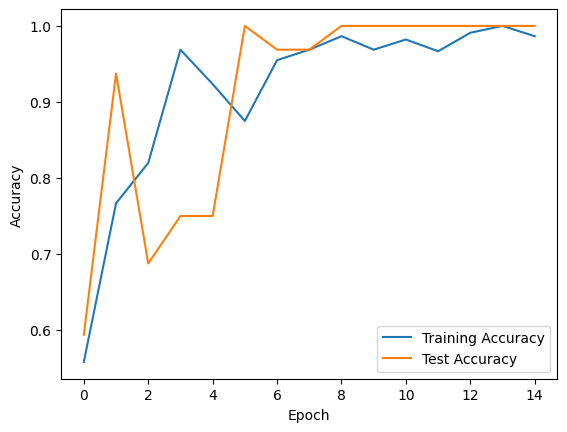

In [ ]:
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_results = model.evaluate(test_generator)

print(f"Test Loss: {test_results[0]}")
print(f"Test Accuracy: {test_results[1]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 6.8695e-04
Test Loss: 0.0005451614852063358
Test Accuracy: 1.0


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

# Define functional version of your CNN
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = Conv2D(36, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', name="last_conv")(x)   # 👈 name this layer
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

functional_model = Model(inputs, outputs)


In [ ]:
import numpy as np
import tensorflow as tf
import cv2

def find_last_conv_layer(model):
    """
    Returns the name of the last 2D convolutional layer in a Keras model.
    Works for Functional, Sequential, and subclassed models (if layers are trackable).
    """
    # Search in reverse for Conv2D-like layers
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    # Fallback: search within nested models
    for layer in reversed(model.layers):
        try:
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub.name
        except AttributeError:
            continue
    raise ValueError("No Conv2D layer found. Ensure your model has convolutional layers.")

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name=None, pred_index=None):
    """
    img_tensor: float32 tensor of shape (1,H,W,C) preprocessed for 'model'
    model: a tf.keras.Model that outputs class probs/logits
    last_conv_layer_name: optional; if None, auto-detect
    pred_index: optional; default uses model's top predicted class
    returns: heatmap in [0,1], shape (feature_map_H, feature_map_W)
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Build a model that maps input -> (last conv outputs, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the class score w.r.t. conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Global-average pooling the gradients over (H, W)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # shape (channels,)

    # Weight the conv outputs with the pooled grads
    conv_outputs = conv_outputs[0]  # (H, W, channels)
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # ReLU + normalize to [0,1]
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_image(orig_bgr, heatmap, alpha=0.35, colormap=cv2.COLORMAP_JET):
    """
    orig_bgr: original image as BGR (OpenCV) array HxWx3 in [0,255]
    heatmap: 2D array in [0,1] (will be resized to image size)
    alpha: how much heatmap to blend
    returns: overlaid BGR image
    """
    h, w = orig_bgr.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    overlay = cv2.addWeighted(heatmap_color, alpha, orig_bgr, 1 - alpha, 0)
    return overlay

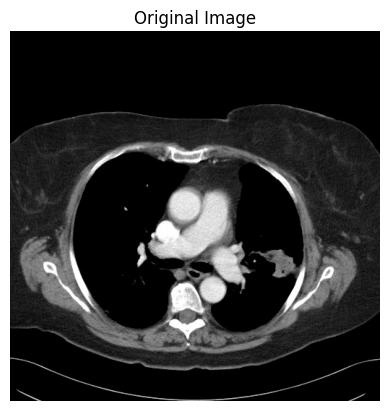

In [ ]:
import matplotlib.pyplot as plt

# Pick a sample image from the test set
img_path = "./test/Cancerous raw images-jpg/Cancerous4.jpg"  # change path to any image

# Read with OpenCV (BGR)
orig_bgr = cv2.imread(img_path)

# Convert to RGB for matplotlib
orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

# Resize and preprocess for model input
img_resized = cv2.resize(orig_rgb, (IMG_WIDTH, IMG_HEIGHT))
x = img_resized.astype("float32") / 255.0
x = np.expand_dims(x, axis=0)  # (1,H,W,C)

plt.imshow(orig_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [ ]:
functional_model.set_weights(model.get_weights())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


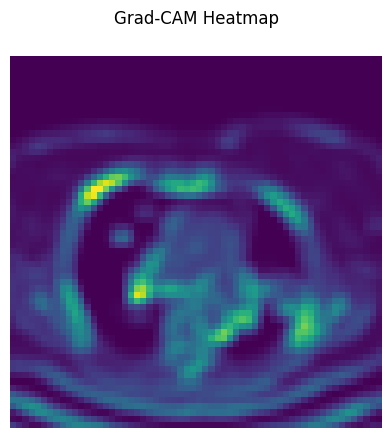

In [ ]:
# Forward pass once
_ = functional_model.predict(x)

# Run Grad-CAM using the last conv layer
heatmap = make_gradcam_heatmap(x, functional_model, last_conv_layer_name="last_conv")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()


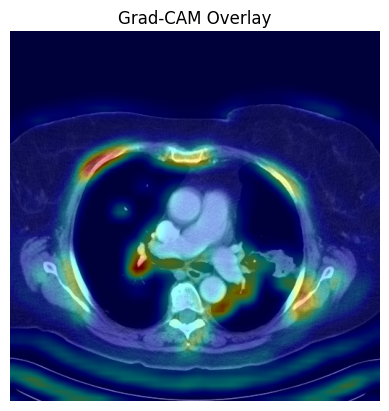

In [ ]:
# Overlay heatmap on the original BGR image
overlay_bgr = overlay_heatmap_on_image(orig_bgr, heatmap, alpha=0.4)

# Convert to RGB for matplotlib
overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(overlay_rgb)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()


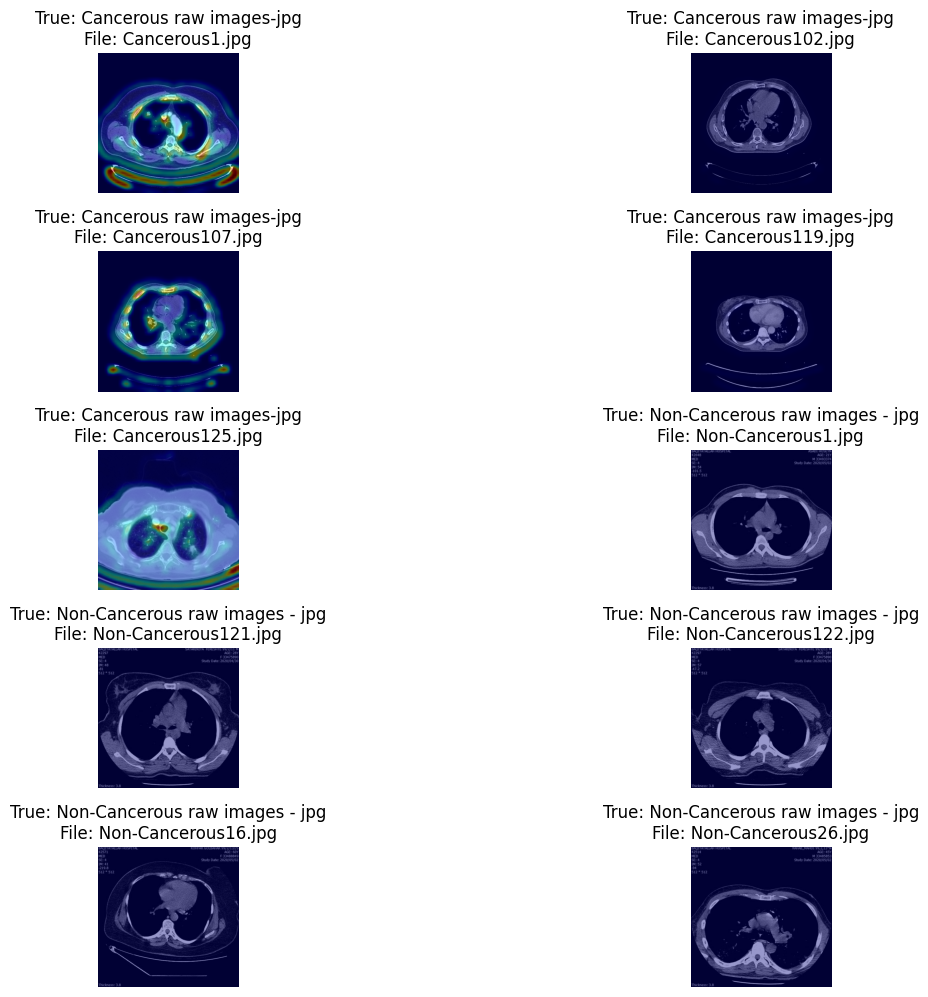

In [ ]:
def show_gradcam_examples(model, generator, num_per_class=5):
    """
    model: trained functional CNN (with 'last_conv' layer)
    generator: Keras test_generator (class_mode='binary')
    num_per_class: how many images from each class to visualize
    """
    class_indices = generator.class_indices   # {'Cancerous raw images-jpg': 0, 'Non-Cancerous raw images - jpg': 1}
    idx_to_class = {v: k for k, v in class_indices.items()}

    cancerous_imgs = []
    non_cancerous_imgs = []

    # Iterate batches until we collect enough from each class
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        for j in range(len(x_batch)):
            label = int(y_batch[j])   # 0 or 1
            path = generator.filepaths[i*generator.batch_size + j]

            if label == 0 and len(cancerous_imgs) < num_per_class:
                cancerous_imgs.append((x_batch[j], path, label))
            elif label == 1 and len(non_cancerous_imgs) < num_per_class:
                non_cancerous_imgs.append((x_batch[j], path, label))

            if len(cancerous_imgs) >= num_per_class and len(non_cancerous_imgs) >= num_per_class:
                break
        if len(cancerous_imgs) >= num_per_class and len(non_cancerous_imgs) >= num_per_class:
            break

    selected_imgs = cancerous_imgs + non_cancerous_imgs

    plt.figure(figsize=(12, 4 * num_per_class))

    for idx, (img_array, path, label) in enumerate(selected_imgs):
        # Original BGR
        orig_bgr = cv2.imread(path)

        # Grad-CAM input
        x = np.expand_dims(img_array, axis=0)

        # Heatmap
        heatmap = make_gradcam_heatmap(x, model, last_conv_layer_name="last_conv")
        overlay_bgr = overlay_heatmap_on_image(orig_bgr, heatmap, alpha=0.4)
        overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

        # Plot
        plt.subplot(num_per_class*2, 2, idx+1)
        plt.imshow(overlay_rgb)
        plt.title(f"True: {idx_to_class[label]}\nFile: {os.path.basename(path)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# ---- Run it ----
show_gradcam_examples(functional_model, test_generator, num_per_class=5)
